<a href="https://colab.research.google.com/github/Trush564/Intellectlab8/blob/main/lab8Trush.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd

# Завантажуємо створений файл
df = pd.read_csv('citrus.csv')
print("Файл завантажено успішно.")
display(df.head(3))

Файл завантажено успішно.


,name,diameter,weight,red,green,blue
0,grapefruit,12.452646,227.745268,148,76,3
1,grapefruit,11.569341,256.110873,140,77,4
2,grapefruit,11.861131,231.097673,151,74,3


In [6]:
from sklearn.preprocessing import StandardScaler

# 1. Факторизація міток (name: orange/grapefruit -> 0/1)
df['name'] = pd.factorize(df['name'], sort=True)[0]

# 2. Виділення ознак та цілі
X = df.drop('name', axis=1).values
Y = df['name'].values

# 3. Стандартизація ознак
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Завдання 2: Факторизацію та стандартизацію виконано.")

Завдання 2: Факторизацію та стандартизацію виконано.


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()
model.add(Dense(64, input_dim=5, activation='relu'))
model.add(Dropout(0.2)) # Впровадження Dropout (20% нейронів вимикаються)
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2)) # Впровадження Dropout
model.add(Dense(2, activation='softmax'))

print("Завдання 3: Шари Dropout додано до архітектури.")

Завдання 3: Шари Dropout додано до архітектури.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
from tensorflow.keras.layers import BatchNormalization

model = Sequential([
    Dense(64, input_dim=5, activation='relu'),
    BatchNormalization(), # Додавання Batch Normalization
    Dropout(0.2),
    Dense(32, activation='relu'),
    BatchNormalization(), # Додавання Batch Normalization
    Dropout(0.2),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Завдання 4: Batch Normalization інтегровано в модель.")

Завдання 4: Batch Normalization інтегровано в модель.


In [9]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Розподіл даних
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2)

# Налаштування Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Завдання 5: Early Stopping налаштовано (patience=5). Початок навчання...")
history = model.fit(X_train, Y_train, epochs=100, validation_split=0.2, callbacks=[early_stop], verbose=1)

Завдання 5: Early Stopping налаштовано (patience=5). Початок навчання...
Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9655 - loss: 0.1014 - val_accuracy: 1.0000 - val_loss: 0.0346
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9933 - loss: 0.0225 - val_accuracy: 1.0000 - val_loss: 0.0036
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9959 - loss: 0.0155 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9967 - loss: 0.0125 - val_accuracy: 1.0000 - val_loss: 7.6970e-04
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9978 - loss: 0.0079 - val_accuracy: 1.0000 - val_loss: 4.7502e-04
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9975 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 3.4469e-04
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9980 - loss: 0.0083 - val_accuracy: 1.0000 - val_loss: 2.4218e-04
Epoch 8/

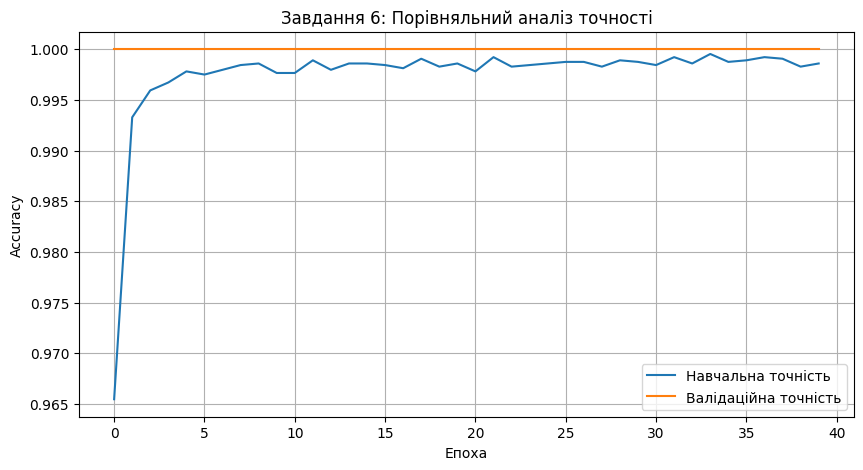

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Навчальна точність')
plt.plot(history.history['val_accuracy'], label='Валідаційна точність')
plt.title('Завдання 6: Порівняльний аналіз точності')
plt.xlabel('Епоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Створення модифікованої моделі
model_optimized = Sequential([
    Dense(64, input_dim=5, activation='relu'),
    BatchNormalization(),  # Оптимізація: нормалізація шарів
    Dropout(0.3),          # Оптимізація: запобігання перенавчанню

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(2, activation='softmax')
])

model_optimized.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Налаштування Early Stopping (зупинка, якщо val_loss не падає 10 епох)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Навчання з валідаційним розподілом
history_opt = model_optimized.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Перевірка результату на тесті
loss, accuracy = model_optimized.evaluate(X_test, Y_test, verbose=0)
print(f"Точність модифікованої моделі: {accuracy*100:.2f}%")